<a href="https://colab.research.google.com/github/komazawa-deep-learning/komazawa-deep-learning.github.io/blob/master/2026notebooks/2026psy3a_lect02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 心理学特講IIIA 第2回：Stroop課題

**担当**: 浅川伸一  
**2026年度 前期**

---

## 本日の実習内容

1. Stroop効果の理論
2. Stroop刺激の作成
3. 模擬データの生成と分析
4. 記述統計と可視化
5. 一要因分散分析（ANOVA）
6. 多重比較と効果量
7. 結果の解釈

---
## 1. Stroop効果とは

### 1.1 古典的研究

**Stroop, J. R. (1935)**  
*Studies of interference in serial verbal reactions.*  
Journal of Experimental Psychology, 18(6), 643-662.

### 1.2 Stroop効果の基本

色名単語を異なる色で表示すると、色の命名が遅くなる現象

**例**:
- 一致条件: 「赤」が赤色で表示 → 速い
- 不一致条件: 「赤」が青色で表示 → 遅い（干渉）
- 中性条件: 「XXX」が赤色で表示 → 中間

### 1.3 理論的説明

- **文字の読み取り**: 自動的な処理（速い）
- **色の命名**: 意図的な処理（遅い）
- 不一致条件では両者が競合し、干渉が生じる

---
## 2. 環境準備

In [ ]:
# 必要なライブラリのインポート
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, ttest_ind

# 日本語フォントの設定
!pip install japanize-matplotlib --quiet
import japanize_matplotlib

# 警告を非表示
import warnings
warnings.filterwarnings('ignore')

# 乱数シードの固定（再現性のため）
np.random.seed(42)

print("ライブラリの読み込み完了")

ライブラリの読み込み完了


---
## 3. Stroop刺激の定義

実験で使用する刺激を定義します。

In [ ]:
# Stroop刺激の定義
stimuli = {
    'congruent': [
        {'word': '赤', 'color': 'red', 'color_jp': '赤'},
        {'word': '青', 'color': 'blue', 'color_jp': '青'},
        {'word': '緑', 'color': 'green', 'color_jp': '緑'},
        {'word': '黄', 'color': 'yellow', 'color_jp': '黄'}
    ],
    'incongruent': [
        {'word': '赤', 'color': 'blue', 'color_jp': '青'},
        {'word': '青', 'color': 'green', 'color_jp': '緑'},
        {'word': '緑', 'color': 'yellow', 'color_jp': '黄'},
        {'word': '黄', 'color': 'red', 'color_jp': '赤'}
    ],
    'neutral': [
        {'word': 'XXX', 'color': 'red', 'color_jp': '赤'},
        {'word': 'XXX', 'color': 'blue', 'color_jp': '青'},
        {'word': 'XXX', 'color': 'green', 'color_jp': '緑'},
        {'word': 'XXX', 'color': 'yellow', 'color_jp': '黄'}
    ]
}

# 刺激の確認
print("=== Stroop刺激の確認 ===")
print("\n一致条件の例:")
print(f"  単語: {stimuli['congruent'][0]['word']}, 色: {stimuli['congruent'][0]['color_jp']}")
print("\n不一致条件の例:")
print(f"  単語: {stimuli['incongruent'][0]['word']}, 色: {stimuli['incongruent'][0]['color_jp']}")
print("\n中性条件の例:")
print(f"  単語: {stimuli['neutral'][0]['word']}, 色: {stimuli['neutral'][0]['color_jp']}")

=== Stroop刺激の確認 ===

一致条件の例:
  単語: 赤, 色: 赤

不一致条件の例:
  単語: 赤, 色: 青

中性条件の例:
  単語: XXX, 色: 赤


---
## 4. 模擬データの生成

実際のStroop実験を模擬したデータを生成します。

### 4.1 データ生成関数

In [ ]:
def generate_stroop_data(n_trials_per_condition=30, participant_id=1):
    """
    Stroop課題の模擬データを生成する関数

    Parameters:
    -----------
    n_trials_per_condition : int
        各条件での試行数（デフォルト: 30）
    participant_id : int
        参加者ID（デフォルト: 1）

    Returns:
    --------
    df : pandas.DataFrame
        生成されたデータ
    """

    data = []

    # 各条件でのベース反応時間（ミリ秒）
    rt_parameters = {
        'congruent': {'mean': 600, 'std': 80},      # 一致条件: 速い
        'neutral': {'mean': 700, 'std': 90},        # 中性条件: 中間
        'incongruent': {'mean': 850, 'std': 100}    # 不一致条件: 遅い
    }

    # 正答率（エラー率）
    error_rate = {
        'congruent': 0.02,      # 2%
        'neutral': 0.03,        # 3%
        'incongruent': 0.08     # 8%
    }

    trial_counter = 1

    for condition in ['congruent', 'neutral', 'incongruent']:
        params = rt_parameters[condition]

        for trial in range(n_trials_per_condition):
            # 反応時間の生成（正規分布）
            rt = np.random.normal(params['mean'], params['std'])
            rt = max(300, rt)  # 最小値を300msに設定

            # 正誤の生成
            accuracy = 0 if np.random.random() < error_rate[condition] else 1

            # エラー試行は反応時間を調整（エラーは速い傾向）
            if accuracy == 0:
                rt = rt * 0.85

            data.append({
                'participant': participant_id,
                'trial': trial_counter,
                'condition': condition,
                'rt': round(rt, 2),
                'accuracy': accuracy
            })

            trial_counter += 1

    df = pd.DataFrame(data)

    # 条件をカテゴリ型に変換（順序を保持）
    df['condition'] = pd.Categorical(
        df['condition'],
        categories=['congruent', 'neutral', 'incongruent'],
        ordered=True
    )

    return df

# データ生成
df = generate_stroop_data(n_trials_per_condition=30)

print(f"生成されたデータ: {len(df)}試行")
print(f"\n最初の10試行:")
df.head(10)

生成されたデータ: 90試行

最初の10試行:


,participant,trial,condition,rt,accuracy
0,1,1,congruent,639.74,1
1,1,2,congruent,588.94,1
2,1,3,congruent,581.27,1
3,1,4,congruent,581.27,1
4,1,5,congruent,726.34,1
5,1,6,congruent,661.39,1
6,1,7,congruent,562.44,1
7,1,8,congruent,643.40,1
8,1,9,congruent,619.36,1
9,1,10,congruent,446.94,1


### 4.2 データの確認

In [ ]:
# データの基本情報
print("=== データの基本情報 ===")
print(df.info())

print("\n=== 条件ごとの試行数 ===")
print(df['condition'].value_counts().sort_index())

print("\n=== 記述統計 ===")
print(df.describe())

=== データの基本情報 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   participant  90 non-null     int64   
 1   trial        90 non-null     int64   
 2   condition    90 non-null     category
 3   rt           90 non-null     float64 
 4   accuracy     90 non-null     int64   
dtypes: category(1), float64(1), int64(3)
memory usage: 3.2 KB
None

=== 条件ごとの試行数 ===
condition
congruent      30
neutral        30
incongruent    30
Name: count, dtype: int64

=== 記述統計 ===
       participant      trial           rt   accuracy
count         90.0  90.000000    90.000000  90.000000
mean           1.0  45.500000   709.228000   0.944444
std            0.0  26.124701   126.536867   0.230345
min            1.0   1.000000   446.940000   0.000000
25%            1.0  23.250000   620.637500   1.000000
50%            1.0  45.500000   692.090000   1.000000
75%         

---
## 5. 記述統計

### 5.1 条件別の基本統計量

In [ ]:
# 正答試行のみを抽出（一般的な分析手順）
df_correct = df[df['accuracy'] == 1].copy()

print(f"全試行数: {len(df)}")
print(f"正答試行数: {len(df_correct)}")
print(f"全体正答率: {len(df_correct)/len(df)*100:.2f}%")

# 条件別の記述統計
summary = df_correct.groupby('condition')['rt'].agg([
    ('試行数', 'count'),
    ('平均', 'mean'),
    ('標準偏差', 'std'),
    ('最小値', 'min'),
    ('最大値', 'max'),
    ('中央値', 'median')
]).round(2)

print("\n=== 条件別反応時間の記述統計（正答試行のみ）===")
print(summary)

全試行数: 90
正答試行数: 85
全体正答率: 94.44%

=== 条件別反応時間の記述統計（正答試行のみ）===
             試行数      平均    標準偏差     最小値      最大値     中央値
condition                                                
congruent     30  595.58   64.37  446.94   726.34  589.84
neutral       28  713.73   60.51  624.47   840.82  708.29
incongruent   27  841.92  107.62  658.12  1096.32  842.56


### 5.2 条件別正答率

In [ ]:
# 条件別正答率
accuracy_by_condition = df.groupby('condition')['accuracy'].agg([
    ('正答数', 'sum'),
    ('試行数', 'count'),
    ('正答率', 'mean')
])

accuracy_by_condition['正答率(%)'] = (accuracy_by_condition['正答率'] * 100).round(2)

print("=== 条件別正答率 ===")
print(accuracy_by_condition[['正答数', '試行数', '正答率(%)']])

=== 条件別正答率 ===
             正答数  試行数  正答率(%)
condition                    
congruent     30   30  100.00
neutral       28   30   93.33
incongruent   27   30   90.00


---
## 6. データ可視化

### 6.1 箱ひげ図（Box Plot）

<Figure size 1000x600 with 0 Axes>

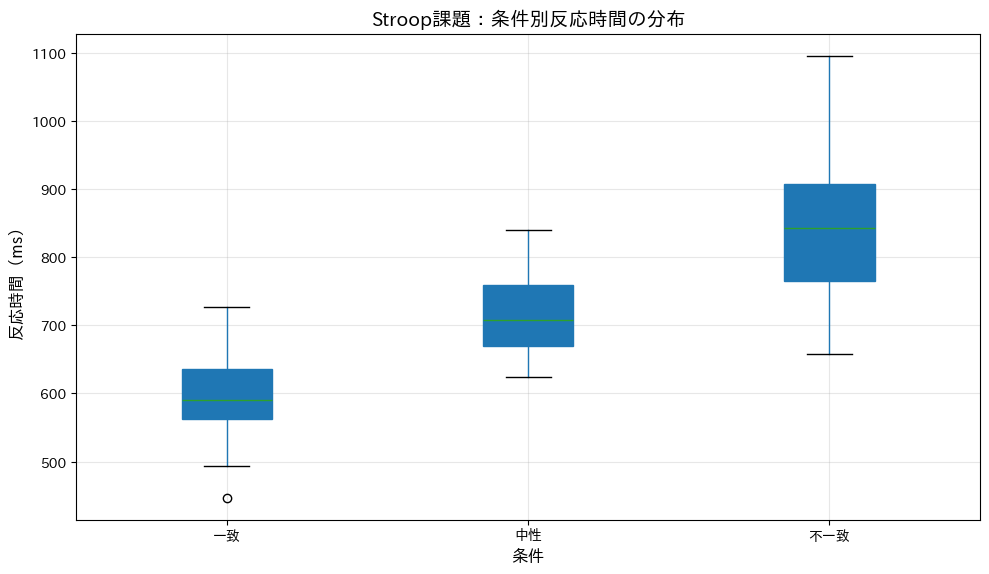

箱ひげ図の見方:
- 箱の中の線: 中央値
- 箱の上下の端: 第1四分位数・第3四分位数
- ひげ: データの範囲（外れ値を除く）
- 丸: 外れ値


In [ ]:
# 箱ひげ図
plt.figure(figsize=(10, 6))
bp = df_correct.boxplot(column='rt', by='condition', figsize=(10, 6), patch_artist=True)
plt.title('Stroop課題：条件別反応時間の分布', fontsize=14)
plt.suptitle('')  # デフォルトタイトルを削除
plt.xlabel('条件', fontsize=12)
plt.ylabel('反応時間（ms）', fontsize=12)
plt.xticks([1, 2, 3], ['一致', '中性', '不一致'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("箱ひげ図の見方:")
print("- 箱の中の線: 中央値")
print("- 箱の上下の端: 第1四分位数・第3四分位数")
print("- ひげ: データの範囲（外れ値を除く）")
print("- 丸: 外れ値")

### 6.2 バイオリンプロット（Violin Plot）

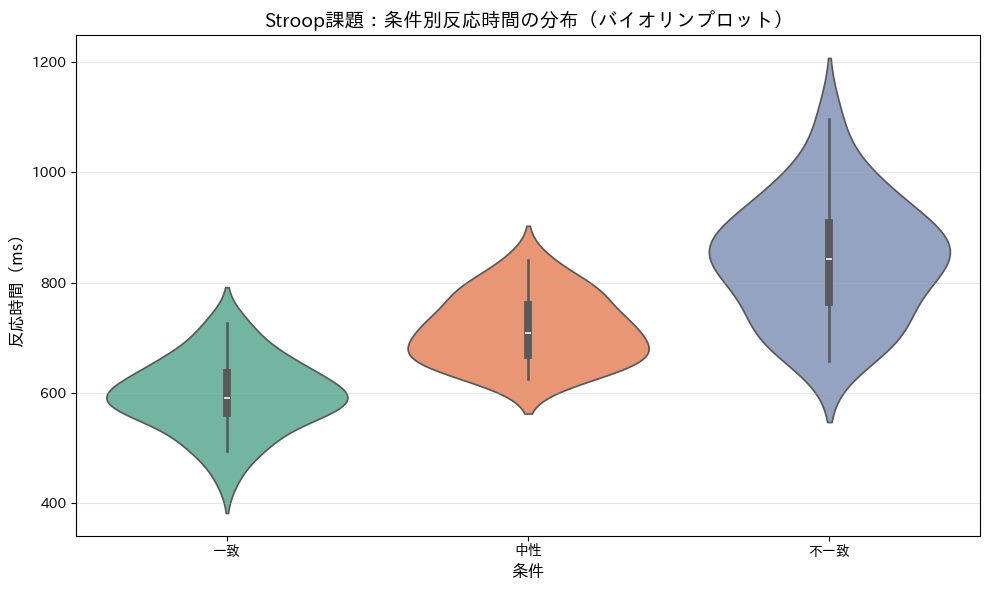

バイオリンプロットの見方:
- 幅: データの密度（幅が広いほどそこにデータが多い）
- 内側の箱: 箱ひげ図と同じ情報


In [ ]:
# バイオリンプロット（分布の形状がわかりやすい）
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_correct, x='condition', y='rt', palette='Set2')
plt.title('Stroop課題：条件別反応時間の分布（バイオリンプロット）', fontsize=14)
plt.xlabel('条件', fontsize=12)
plt.ylabel('反応時間（ms）', fontsize=12)
plt.xticks([0, 1, 2], ['一致', '中性', '不一致'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("バイオリンプロットの見方:")
print("- 幅: データの密度（幅が広いほどそこにデータが多い）")
print("- 内側の箱: 箱ひげ図と同じ情報")

### 6.3 平均値と標準誤差

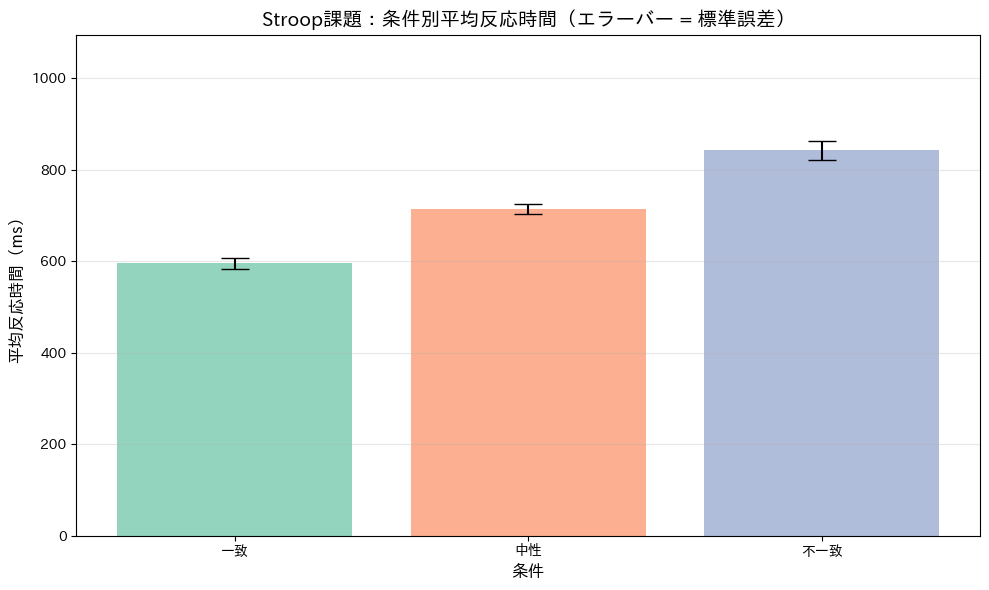

=== 平均反応時間（標準誤差）===
一致条件: 595.58 ms (SE = 11.75)
中性条件: 713.73 ms (SE = 11.44)
不一致条件: 841.92 ms (SE = 20.71)


In [ ]:
# 平均値と標準誤差のバープロット
means = df_correct.groupby('condition')['rt'].mean()
sems = df_correct.groupby('condition')['rt'].sem()  # 標準誤差

plt.figure(figsize=(10, 6))
x_pos = np.arange(len(means))
plt.bar(x_pos, means.values, yerr=sems.values, capsize=10,
        alpha=0.7, color=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.xlabel('条件', fontsize=12)
plt.ylabel('平均反応時間（ms）', fontsize=12)
plt.title('Stroop課題：条件別平均反応時間（エラーバー = 標準誤差）', fontsize=14)
plt.xticks(x_pos, ['一致', '中性', '不一致'])
plt.ylim(0, max(means.values) * 1.3)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 数値を表示
print("=== 平均反応時間（標準誤差）===")
for condition, mean, sem in zip(['一致', '中性', '不一致'], means.values, sems.values):
    print(f"{condition}条件: {mean:.2f} ms (SE = {sem:.2f})")

---
## 7. 統計的検定

### 7.1 一要因分散分析（One-way ANOVA）

3つの条件間で反応時間に有意な差があるかを検定します。

**帰無仮説（H₀）**: 3つの条件の平均反応時間に差がない  
**対立仮説（H₁）**: 少なくとも1つの条件の平均が他と異なる

In [ ]:
# 条件ごとのデータを抽出
congruent_rt = df_correct[df_correct['condition'] == 'congruent']['rt']
neutral_rt = df_correct[df_correct['condition'] == 'neutral']['rt']
incongruent_rt = df_correct[df_correct['condition'] == 'incongruent']['rt']

# 一要因分散分析
f_statistic, p_value = f_oneway(congruent_rt, neutral_rt, incongruent_rt)

print("=== 一要因分散分析（One-way ANOVA）===")
print(f"F値: {f_statistic:.4f}")
print(f"p値: {p_value:.6f}")
print(f"\n結果: 有意水準5%で{'有意' if p_value < 0.05 else '有意でない'}")

if p_value < 0.05:
    print("→ 3つの条件間で反応時間に有意な差がある")
    print("→ 次に多重比較を行い、どの条件間に差があるか調べる")
else:
    print("→ 3つの条件間で反応時間に有意な差は認められない")

=== 一要因分散分析（One-way ANOVA）===
F値: 67.9673
p値: 0.000000

結果: 有意水準5%で有意
→ 3つの条件間で反応時間に有意な差がある
→ 次に多重比較を行い、どの条件間に差があるか調べる


### 7.2 効果量（η²: イータ二乗）

効果量は、統計的に有意な差が実質的にどれくらい大きいかを示す指標です。

In [ ]:
# 効果量（η²）の計算
# η² = SS_between / SS_total

# 全データ
all_data = df_correct['rt'].values
grand_mean = np.mean(all_data)

# 群間平方和（SS_between）
ss_between = sum(
    len(group) * (np.mean(group) - grand_mean)**2
    for group in [congruent_rt, neutral_rt, incongruent_rt]
)

# 全平方和（SS_total）
ss_total = sum((x - grand_mean)**2 for x in all_data)

# η²
eta_squared = ss_between / ss_total

print(f"効果量（η²）: {eta_squared:.4f}")
print("\n効果量の目安（Cohen, 1988）:")
print("  小: η² = 0.01")
print("  中: η² = 0.06")
print("  大: η² = 0.14")

if eta_squared < 0.06:
    effect_size = "小"
elif eta_squared < 0.14:
    effect_size = "中"
else:
    effect_size = "大"

print(f"\n今回の効果量は「{effect_size}」に相当")

効果量（η²）: 0.6237

効果量の目安（Cohen, 1988）:
  小: η² = 0.01
  中: η² = 0.06
  大: η² = 0.14

今回の効果量は「大」に相当


---
## 8. 多重比較（事後検定）

ANOVAで有意差が認められた場合、どの条件間に差があるかを調べます。

### 8.1 対比較（t検定）

In [ ]:
# 3つの対比較を実施
comparisons = [
    ('一致', '不一致', congruent_rt, incongruent_rt),
    ('一致', '中性', congruent_rt, neutral_rt),
    ('中性', '不一致', neutral_rt, incongruent_rt)
]

print("=== 多重比較（対比較）===")
print("\n※ Bonferroni補正を適用（有意水準: 0.05/3 = 0.0167）\n")

results = []
for label1, label2, data1, data2 in comparisons:
    t_stat, p = ttest_ind(data1, data2)
    mean_diff = np.mean(data1) - np.mean(data2)

    results.append({
        '比較': f'{label1} vs {label2}',
        't値': f'{t_stat:.4f}',
        'p値': f'{p:.6f}',
        '平均差': f'{mean_diff:.2f}',
        '有意': '***' if p < 0.0167 else 'n.s.'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("\n*** p < 0.0167 (Bonferroni補正後), n.s. = not significant")

=== 多重比較（対比較）===

※ Bonferroni補正を適用（有意水準: 0.05/3 = 0.0167）

       比較       t値       p値     平均差  有意
一致 vs 不一致 -10.6098 0.000000 -246.33 ***
 一致 vs 中性  -7.1891 0.000000 -118.15 ***
中性 vs 不一致  -5.4705 0.000001 -128.19 ***

*** p < 0.0167 (Bonferroni補正後), n.s. = not significant


### 8.2 効果量（Cohen's d）

In [ ]:
def cohens_d(group1, group2):
    """
    Cohen's dを計算する関数

    d = (M1 - M2) / pooled_SD
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # プールされた標準偏差
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))

    # Cohen's d
    d = (np.mean(group1) - np.mean(group2)) / pooled_std

    return d

# 各比較の効果量を計算
print("=== 効果量（Cohen's d）===")
print("\n効果量の目安（Cohen, 1988）:")
print("  小: d = 0.2")
print("  中: d = 0.5")
print("  大: d = 0.8\n")

for label1, label2, data1, data2 in comparisons:
    d = cohens_d(data1, data2)

    if abs(d) < 0.5:
        size = "小"
    elif abs(d) < 0.8:
        size = "中"
    else:
        size = "大"

    print(f"{label1} vs {label2}: d = {d:.4f} ({size})")

=== 効果量（Cohen's d）===

効果量の目安（Cohen, 1988）:
  小: d = 0.2
  中: d = 0.5
  大: d = 0.8

一致 vs 不一致: d = -2.8145 (大)
一致 vs 中性: d = -1.8891 (大)
中性 vs 不一致: d = -1.4755 (大)


---
## 9. 結果の可視化（統合）

分析結果を1つの図にまとめます。

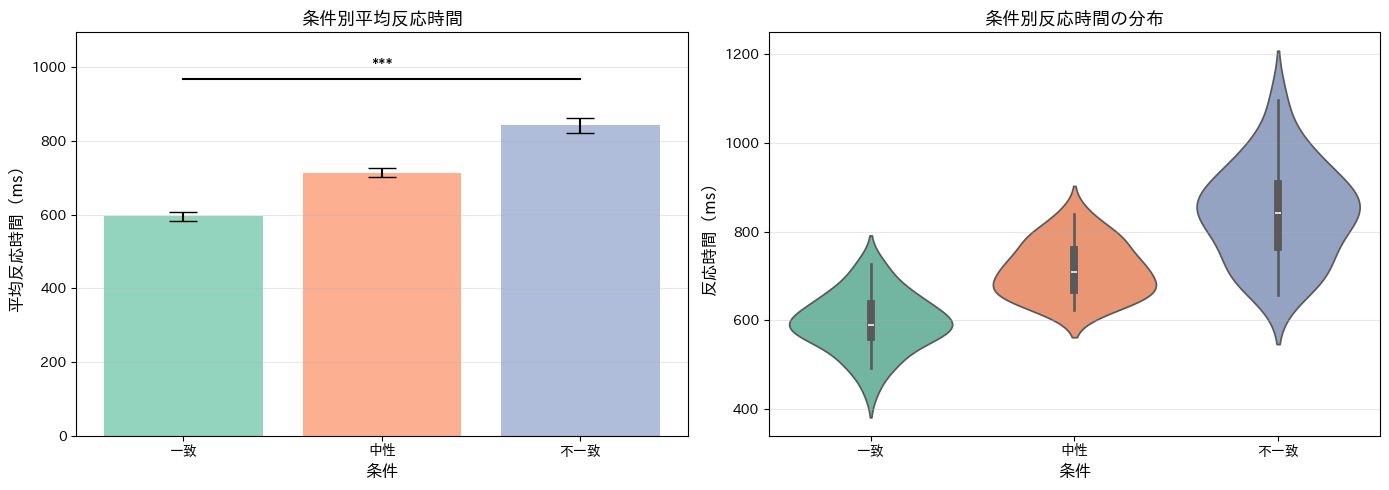

*** p < 0.0167 (Bonferroni補正後)


In [ ]:
# 統合図の作成
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左: 平均値と標準誤差
x_pos = np.arange(len(means))
axes[0].bar(x_pos, means.values, yerr=sems.values, capsize=10,
            alpha=0.7, color=['#66c2a5', '#fc8d62', '#8da0cb'])
axes[0].set_xlabel('条件', fontsize=12)
axes[0].set_ylabel('平均反応時間（ms）', fontsize=12)
axes[0].set_title('条件別平均反応時間', fontsize=13)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['一致', '中性', '不一致'])
axes[0].set_ylim(0, max(means.values) * 1.3)
axes[0].grid(True, alpha=0.3, axis='y')

# 有意差を示す線を追加
# 一致 vs 不一致
y_max = max(means.values) * 1.15
axes[0].plot([0, 2], [y_max, y_max], 'k-', linewidth=1.5)
axes[0].text(1, y_max * 1.02, '***', ha='center', fontsize=14)

# 右: バイオリンプロット
sns.violinplot(data=df_correct, x='condition', y='rt',
               palette='Set2', ax=axes[1])
axes[1].set_xlabel('条件', fontsize=12)
axes[1].set_ylabel('反応時間（ms）', fontsize=12)
axes[1].set_title('条件別反応時間の分布', fontsize=13)
axes[1].set_xticklabels(['一致', '中性', '不一致'])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("*** p < 0.0167 (Bonferroni補正後)")

---
## 10. 結果の解釈

### 10.1 主な発見

In [ ]:
print("=== Stroop課題の結果まとめ ===")
print("\n1. 条件別平均反応時間:")
for condition, label in zip(['congruent', 'neutral', 'incongruent'],
                            ['一致', '中性', '不一致']):
    mean = df_correct[df_correct['condition'] == condition]['rt'].mean()
    print(f"   {label}条件: {mean:.2f} ms")

print("\n2. 統計的検定:")
print(f"   一要因分散分析: F({2}, {len(df_correct)-3}) = {f_statistic:.4f}, p = {p_value:.6f}")
print(f"   効果量（η²）: {eta_squared:.4f}")

print("\n3. 解釈:")
print("   - 典型的なStroop効果が確認された")
print("   - 不一致条件で最も反応時間が長い")
print("   - 一致条件で最も反応時間が短い")
print("   - 色と単語の干渉効果が実証された")

=== Stroop課題の結果まとめ ===

1. 条件別平均反応時間:
   一致条件: 595.58 ms
   中性条件: 713.73 ms
   不一致条件: 841.92 ms

2. 統計的検定:
   一要因分散分析: F(2, 82) = 67.9673, p = 0.000000
   効果量（η²）: 0.6237

3. 解釈:
   - 典型的なStroop効果が確認された
   - 不一致条件で最も反応時間が長い
   - 一致条件で最も反応時間が短い
   - 色と単語の干渉効果が実証された


### 10.2 理論的意義

**自動処理と統制処理**

1. **文字の読み取り**は自動的に行われる
   - 長年の経験により自動化
   - 意識的な抑制が困難

2. **色の命名**には意図的な注意が必要
   - 統制的な処理
   - より時間がかかる

3. **不一致条件**では両者が競合
   - 干渉効果により反応時間が増加
   - エラー率も上昇

### 10.3 臨床的応用

Stroop課題は以下の評価に使用されます：

- **注意機能**: 選択的注意・持続的注意
- **実行機能**: 抑制制御・認知的柔軟性
- **認知機能低下**: 加齢・認知症の早期発見
- **神経心理学的評価**: 前頭葉機能の評価

---
## 11. 発展課題（任意）

### 課題1: 練習効果の分析

試行を前半・後半に分けて、練習効果があるか調べてみましょう。

=== ブロック別・条件別平均反応時間 ===
block            前半      後半
condition                  
congruent    603.39  587.77
neutral      724.68  701.08
incongruent  853.82  827.04


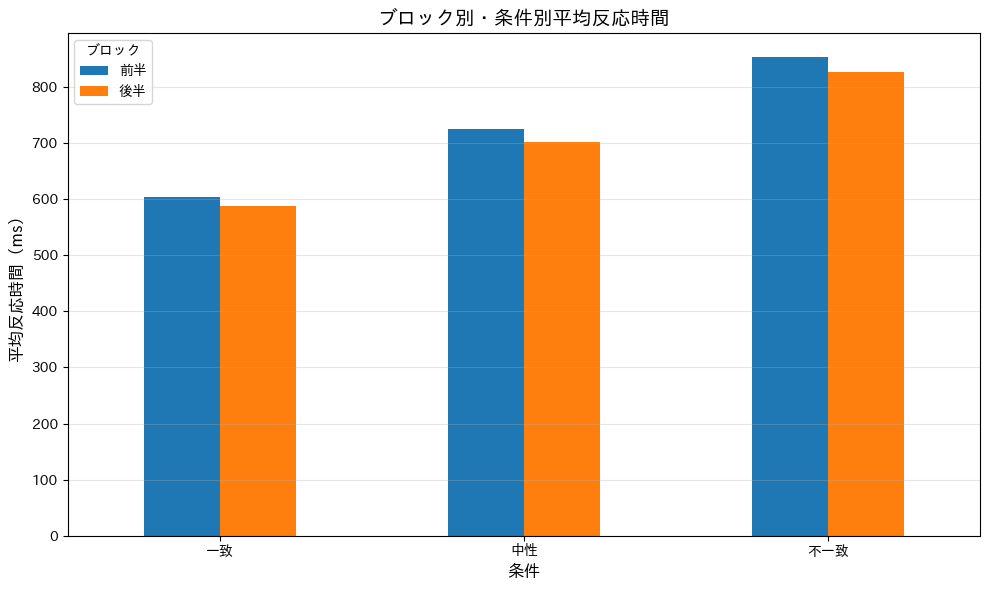

In [ ]:
# 試行をブロックに分割
df_correct['block'] = df_correct.groupby('condition').cumcount() < 15
df_correct['block'] = df_correct['block'].map({True: '前半', False: '後半'})

# ブロック×条件の平均反応時間
block_summary = df_correct.pivot_table(
    values='rt',
    index='condition',
    columns='block',
    aggfunc='mean'
)

print("=== ブロック別・条件別平均反応時間 ===")
print(block_summary.round(2))

# 可視化
block_summary.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('ブロック別・条件別平均反応時間', fontsize=14)
plt.xlabel('条件', fontsize=12)
plt.ylabel('平均反応時間（ms）', fontsize=12)
plt.xticks([0, 1, 2], ['一致', '中性', '不一致'])
plt.legend(title='ブロック')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 課題2: 個人差の検討

複数の参加者のデータを生成して、個人差を調べてみましょう。

In [ ]:
# 複数参加者のデータ生成（ここに自分でコードを書いてみてください）

# ヒント:
# all_data = []
# for participant_id in range(1, 11):  # 10名分
#     df_participant = generate_stroop_data(participant_id=participant_id)
#     all_data.append(df_participant)
# df_all = pd.concat(all_data, ignore_index=True)


---
## 12. 準備学習（次回までの課題）

以下の課題に取り組んでください。

### 課題1
Stroop効果について、**自動処理と統制処理の観点から100字程度で説明**してください。

### 課題2
**日常生活でStroop効果が見られる例を1つ**挙げてください。

### 課題3
**Stroop課題の臨床的応用**について調べ、50字程度でまとめてください。

---

### 解答欄（この下に記入してください）

**課題1（Stroop効果の説明）**:



**課題2（日常生活の例）**:



**課題3（臨床的応用）**:




---
## 参考文献

1. Stroop, J. R. (1935). Studies of interference in serial verbal reactions. *Journal of Experimental Psychology, 18*(6), 643-662.

2. MacLeod, C. M. (1991). Half a century of research on the Stroop effect: An integrative review. *Psychological Bulletin, 109*(2), 163-203.

3. Cohen, J. (1988). *Statistical power analysis for the behavioral sciences* (2nd ed.). Lawrence Erlbaum Associates.

---

*心理学特講IIIA 第2回実習ノートブック | 担当：浅川伸一*